# Group 4 · Lab A — Attention from Scratch: the Long-Range Lookup

Group 3 ended on a wall: RNNs lose information (and gradient) across long
distances, and a single context vector cannot scale. This lab builds the fix --
scaled dot-product attention -- by hand, and shows two things:

1. On a task that requires reading a token from an arbitrary distance away, a
   one-layer self-attention model stays perfect at every sequence length while an
   LSTM strains and a plain RNN collapses.
2. The attention weights are interpretable: we can see the model look directly at
   the token it needs, wherever it is.

No `nn.Transformer`, no `nn.MultiheadAttention` -- we write the attention math
ourselves, exactly as in the notes.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math, random
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

def seed_all(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)

device: cpu


## Part 1 - Scaled dot-product attention, by hand

Straight from Card 2 of the notes:

    Attention(Q, K, V) = softmax( (Q K^T) / sqrt(d_k) ) V

- Q (B, Tq, d): what each query position is looking for
- K (B, Tk, d): what each source position offers for matching
- V (B, Tk, dv): what each source position contributes if attended to

The dot product Q K^T scores every query against every key; dividing by sqrt(d_k)
keeps the scores from saturating softmax; softmax turns scores into weights that
sum to 1; the output is the weighted sum of values.

In [2]:
def scaled_dot_product_attention(Q, K, V):
    d_k = Q.size(-1)
    scores = Q @ K.transpose(-2, -1) / math.sqrt(d_k)   # (B, Tq, Tk)
    weights = F.softmax(scores, dim=-1)                 # rows sum to 1
    out = weights @ V                                   # (B, Tq, dv)
    return out, weights

# sanity check: shapes and that each query's weights sum to 1
seed_all(0)
Q = torch.randn(2, 3, 8); K = torch.randn(2, 5, 8); V = torch.randn(2, 5, 8)
out, w = scaled_dot_product_attention(Q, K, V)
print("out shape:", tuple(out.shape), " (expect (2, 3, 8))")
print("weights shape:", tuple(w.shape), " (expect (2, 3, 5))")
print("each query's weights sum to:", float(w.sum(-1).mean()), " (expect 1.0)")

out shape: (2, 3, 8)  (expect (2, 3, 8))
weights shape: (2, 3, 5)  (expect (2, 3, 5))
each query's weights sum to: 1.0  (expect 1.0)


## Part 2 - A task that needs a long-range link: recall

Tokens 0-8 are filler. Tokens 9-17 are a single "marked" value: a marked value v
appears as token 9+v. Each sequence is all filler except for ONE marked token
dropped at a random position. The label is that marked value (0-8).

To solve it, the model must locate the marked token -- which can be anywhere --
and read its value. This is a content-based lookup. Attention can jump straight to
it regardless of distance; an RNN must detect it and carry its value, in the
hidden state, all the way to the end -- the exact long-range-memory problem from
Group 3.

Note we deliberately use NO positional encoding here: the task is purely
content-addressed (find the distinctive token), so position is irrelevant to
finding it. We add positional encoding in Lab B, where order matters.

In [3]:
NFILL, VOCAB, NCLS = 9, 18, 9

def make_recall(n, T, seed=0):
    seed_all(seed)
    X = torch.randint(0, NFILL, (n, T))        # all filler
    p = torch.randint(0, T, (n,))              # marked position
    val = torch.randint(0, NCLS, (n,))         # marked value
    X[torch.arange(n), p] = 9 + val            # drop the marked token in
    return X, val, p

Xs, ys, ps = make_recall(1, 20, seed=1)
print("sequence:", Xs[0].tolist())
print("marked token 9-17 sits at position", int(ps[0]), "-> value", int(ys[0]))

sequence: [4, 5, 0, 5, 7, 1, 2, 5, 8, 0, 15, 3, 1, 8, 4, 0, 3, 6, 2, 7]
marked token 9-17 sits at position 10 -> value 6


In [4]:
class AttnClassifier(nn.Module):
    """One learned query attends over the sequence (CLS-style), then classifies."""
    def __init__(self, d=32):
        super().__init__()
        self.embed = nn.Embedding(VOCAB, d)
        self.q = nn.Parameter(torch.randn(1, 1, d) * 0.1)   # single learned query
        self.Wk = nn.Linear(d, d)
        self.Wv = nn.Linear(d, d)
        self.fc = nn.Linear(d, NCLS)
    def forward(self, x, return_attn=False):
        e = self.embed(x)                        # (B, T, d)
        B = x.size(0)
        Q = self.q.expand(B, -1, -1)             # (B, 1, d)
        K = self.Wk(e); V = self.Wv(e)
        out, w = scaled_dot_product_attention(Q, K, V)   # out (B,1,d), w (B,1,T)
        logits = self.fc(out[:, 0])
        if return_attn:
            return logits, w[:, 0]               # attention over positions: (B, T)
        return logits

class RNNClassifier(nn.Module):
    def __init__(self, d=32, kind="lstm"):
        super().__init__()
        self.embed = nn.Embedding(VOCAB, d)
        self.rnn = {"rnn": nn.RNN, "lstm": nn.LSTM}[kind](d, d, batch_first=True)
        self.fc = nn.Linear(d, NCLS)
    def forward(self, x):
        e = self.embed(x); o, _ = self.rnn(e)
        return self.fc(o[:, -1])

In [5]:
def train_eval(model, T, seed=0, epochs=12, lr=3e-3):
    seed_all(seed); model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossf = nn.CrossEntropyLoss()
    Xtr, ytr, _ = make_recall(4000, T, seed=seed)
    Xte, yte, _ = make_recall(800, T, seed=seed + 100)
    Xtr, ytr, Xte, yte = Xtr.to(device), ytr.to(device), Xte.to(device), yte.to(device)
    for ep in range(epochs):
        model.train(); perm = torch.randperm(len(ytr))
        for i in range(0, len(ytr), 128):
            idx = perm[i:i+128]; opt.zero_grad()
            loss = lossf(model(Xtr[idx]), ytr[idx]); loss.backward(); opt.step()
    model.eval()
    with torch.no_grad():
        acc = (model(Xte).argmax(1) == yte).float().mean().item()
    return acc

print(f"{'T':>4} {'attention':>10} {'lstm':>8} {'rnn':>8}   (chance = {1/NCLS:.3f})")
for T in [10, 30, 60]:
    a = train_eval(AttnClassifier(), T)
    l = train_eval(RNNClassifier(kind="lstm"), T)
    r = train_eval(RNNClassifier(kind="rnn"), T)
    print(f"{T:>4} {a:>10.3f} {l:>8.3f} {r:>8.3f}")

   T  attention     lstm      rnn   (chance = 0.111)
  10      1.000    1.000    1.000
  30      1.000    1.000    0.349
  60      1.000    0.902    0.236


## Part 3 - Watch attention find the token

The accuracy numbers say attention solves the task; the attention weights say
*how*. We train the attention model on length-50 sequences, then for a batch of
test examples we read out the weight it placed on each position. If the mechanism
works the way we claim, the weight should spike exactly on the marked token --
wherever it happens to be.

mean attention weight ON the marked position: 0.974
fraction where argmax(attention) == marked position: 1.000


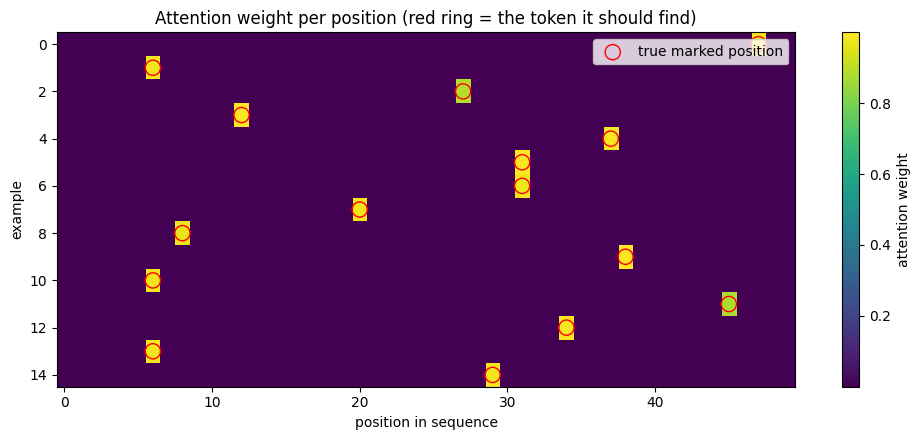

In [6]:
seed_all(0)
T = 50
model = AttnClassifier().to(device)
opt = torch.optim.Adam(model.parameters(), lr=3e-3)
lossf = nn.CrossEntropyLoss()
Xtr, ytr, _ = make_recall(4000, T, seed=0)
Xtr, ytr = Xtr.to(device), ytr.to(device)
for ep in range(12):
    model.train(); perm = torch.randperm(len(ytr))
    for i in range(0, len(ytr), 128):
        idx = perm[i:i+128]; opt.zero_grad()
        loss = lossf(model(Xtr[idx]), ytr[idx]); loss.backward(); opt.step()

model.eval()
Xte, yte, pte = make_recall(500, T, seed=321)
with torch.no_grad():
    logits, attn = model(Xte.to(device), return_attn=True)   # attn: (B, T)
attn = attn.cpu()

# localization stats
on_mark = attn[torch.arange(len(pte)), pte]                  # weight on the true marked position
argmax_hit = (attn.argmax(1) == pte).float().mean().item()
print(f"mean attention weight ON the marked position: {on_mark.mean():.3f}")
print(f"fraction where argmax(attention) == marked position: {argmax_hit:.3f}")

# heatmap: 15 examples, attention over position, with the true marked position marked
k = 15
fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(attn[:k], aspect="auto", cmap="viridis")
ax.scatter(pte[:k], range(k), marker="o", facecolors="none",
           edgecolors="red", s=120, label="true marked position")
ax.set_xlabel("position in sequence")
ax.set_ylabel("example")
ax.set_title("Attention weight per position (red ring = the token it should find)")
ax.legend(loc="upper right")
fig.colorbar(im, ax=ax, label="attention weight")
plt.tight_layout()
plt.show()

## Lab A - concept check

**Q1. The attention model stayed at 1.000 accuracy from length 10 to 60 while the
LSTM fell off. What property of attention causes accuracy to be flat in sequence
length, and what does it cost?**

The path length between the query and any input position is constant -- a single
attention step -- regardless of how far apart they are. The query computes a score
against every position directly and in parallel, so a token 60 steps away is no
harder to reach than one 2 steps away. The LSTM, by contrast, must carry the
marked value in its hidden state across every intervening step, and that memory
degrades with distance (the Group 3 vanishing-gradient-over-time problem), so its
accuracy falls as sequences grow. The cost of attention's constant path is
quadratic compute and memory: scoring every position against every other is
O(n^2), where the RNN was O(n). Attention buys distance-independence and
parallelism at the price of scaling badly in sequence length.

**Q2. We used NO positional encoding and the model still hit 100%. Would adding
positional encoding help here, and when would its absence break a task?**

It would not help here and could even distract, because this task is purely
content-addressed: the marked token is identifiable by its embedding alone (it
lives in the 9-17 range), so the query can find it by content without knowing any
position. Positional encoding becomes essential the moment the answer depends on
*where* a token is or on the *order* of tokens -- for example "return the token
immediately after the marked one", "is this sequence in ascending order", or any
language task where "dog bites man" must differ from "man bites dog". Without
position information self-attention treats its input as an unordered set, so any
task whose label changes under shuffling cannot be solved. This task is invariant
to where the marked token sits, which is exactly why we could omit it -- and why
Lab B, where order matters, puts it back.

**Q3. The query here is a single learned vector (a CLS-style query), not derived
from the input. How does this differ from full self-attention, and why was the
simpler version enough?**

In full self-attention every position produces its own query from its own
embedding, so the layer outputs a new representation for every position (an
N-to-N operation). Here we have exactly one fixed, learned query that is the same
for every input, so the layer produces a single pooled vector (an N-to-1
operation) -- essentially a learned, content-based pooling over the sequence. It
was enough because the task needs only one piece of information retrieved once (the
marked value), so a single query that learns "look for the token in the marked
range" suffices. Full self-attention is needed when every position must be
re-represented in light of all the others -- for instance when later layers build
on per-position outputs, or when many different relationships must be computed
across the sequence at once. Lab B and the project use the full version; this lab
isolates the attention operation in its simplest useful form.